In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
model = MobileNetV2(weights='imagenet')

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


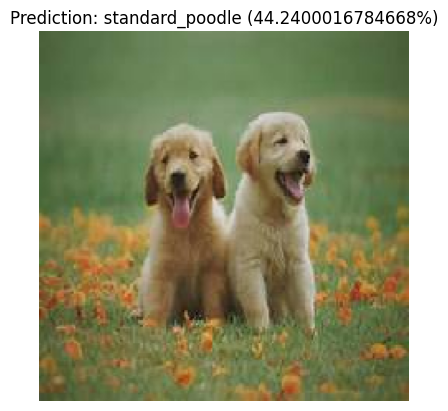

Top 3 Predictions:
1: standard_poodle - 44.2400016784668%
2: golden_retriever - 9.6899995803833%
3: Bedlington_terrier - 7.610000133514404%


In [12]:
local_path = '/content/OIP.jpg'

try:
    img = image.load_img(local_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    preds = model.predict(x)
    results = decode_predictions(preds, top=3)[0]
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {results[0][1]} ({round(results[0][2]*100, 2)}%)")
    plt.show()

    print("Top 3 Predictions:")
    for i, res in enumerate(results):
        print(f"{i+1}: {res[1]} - {round(res[2]*100, 2)}%")

except Exception as e:
    print(f"Workflow Error: {e}. Make sure the file path is correct!")